# Optimizers — Illustrated Tour

> Companion to the **Illustrated ML** *Optimization* page.

Every iterative learner solves $\min_\theta\,\mathcal L(\theta)$.
The choice of update rule changes **how fast** we get there and **whether we get there at all**.

| Optimizer | Update (one parameter) | Idea |
|---|---|---|
| GD (Gradient Descent)       | $\theta \leftarrow \theta - \eta\,g$ | follow the slope |
| Momentum | $v \leftarrow \beta v + g;\;\; \theta \leftarrow \theta - \eta v$ | accumulate velocity |
| Nesterov | look-ahead gradient                  | corrected momentum |
| Adagrad (Adaptive Gradient Algorithm)  | per-parameter $\eta / \sqrt{\sum g^2}$ | cool down each axis |
| RMSProp (Root Mean Square Propagation)  | per-parameter $\eta / \sqrt{\text{EMA}(g^2)}$ | windowed Adagrad |
| Adam (Adaptive Moment Estimation)     | momentum + RMSProp + bias correction | the workhorse |

> **EMA** = Exponential Moving Average

## The picture — gradient steps roll downhill on the loss surface

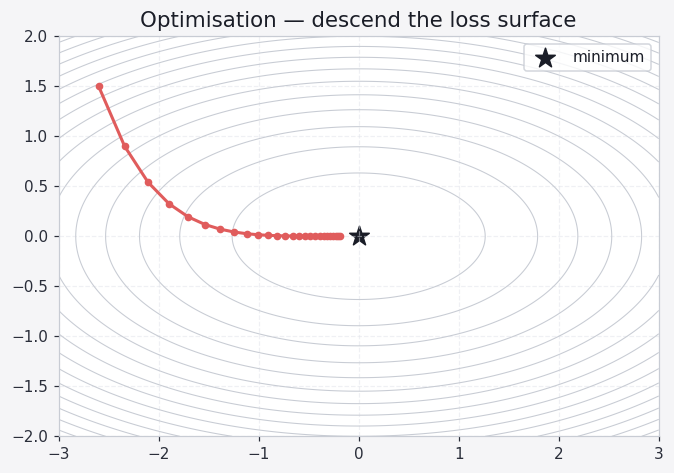

In [1]:
# (schematic — drawn from smooth curves, not measured)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrow, FancyBboxPatch, Ellipse, Rectangle, Circle, FancyArrowPatch
plt.rcParams.update({
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':14,'axes.labelsize':12,
    'legend.facecolor':'#ffffff','legend.edgecolor':'#c8ccd4','figure.dpi':110,
})
P = ['#5b9bd5','#e05c5c','#f4b942','#7ecba1','#56b6c2','#c678dd','#888fa5','#d68a3c']
xx, yy = np.meshgrid(np.linspace(-3, 3, 200), np.linspace(-2, 2, 200))
Z = 0.5*(xx**2 + 4*yy**2)
fig, ax = plt.subplots(figsize=(9, 4.4))
ax.contour(xx, yy, Z, levels=15, colors='#c8ccd4', linewidths=0.7)
p = np.array([-2.6, 1.5]); traj = [p.copy()]
for _ in range(25):
    g = np.array([p[0], 4*p[1]]); p = p - 0.1*g; traj.append(p.copy())
T = np.array(traj)
ax.plot(T[:,0], T[:,1], color=P[1], lw=2, marker='o', markersize=4)
ax.scatter(0, 0, marker='*', s=180, color='#1a1d27', label='minimum')
ax.set_aspect('equal'); ax.set_title('Optimisation — descend the loss surface')
ax.legend(); ax.grid(True); plt.tight_layout(); plt.show()


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

PLT_STYLE = {
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':14,'axes.labelsize':12,
    'xtick.labelsize':10,'ytick.labelsize':10,'legend.fontsize':10,'legend.facecolor':'#ffffff',
    'legend.edgecolor':'#c8ccd4','figure.dpi':110,
}
plt.rcParams.update(PLT_STYLE)
PALETTE = ['#5b9bd5','#e05c5c','#f4b942','#7ecba1','#56b6c2','#c678dd','#888fa5','#d68a3c']

# A challenging 2-D landscape with a curved valley + a flat saddle region.
def f(x, y):
    return 0.5*(x**2 + 10*y**2) + 0.4*np.sin(3*x)*np.cos(3*y)

def grad(p):
    x, y = p
    gx = x + 1.2*np.cos(3*x)*np.cos(3*y)
    gy = 10*y - 1.2*np.sin(3*x)*np.sin(3*y)
    return np.array([gx, gy])

xx, yy = np.meshgrid(np.linspace(-3, 3, 200), np.linspace(-1.2, 1.2, 200))
ZZ = f(xx, yy)
print('Loss surface ready (anisotropic + small-amplitude wiggles).')


Loss surface ready (anisotropic + small-amplitude wiggles).


---
## All seven optimizers from the same start

Run each for 80 steps from $(-2.6, 1.0)$ and overlay the trajectories.


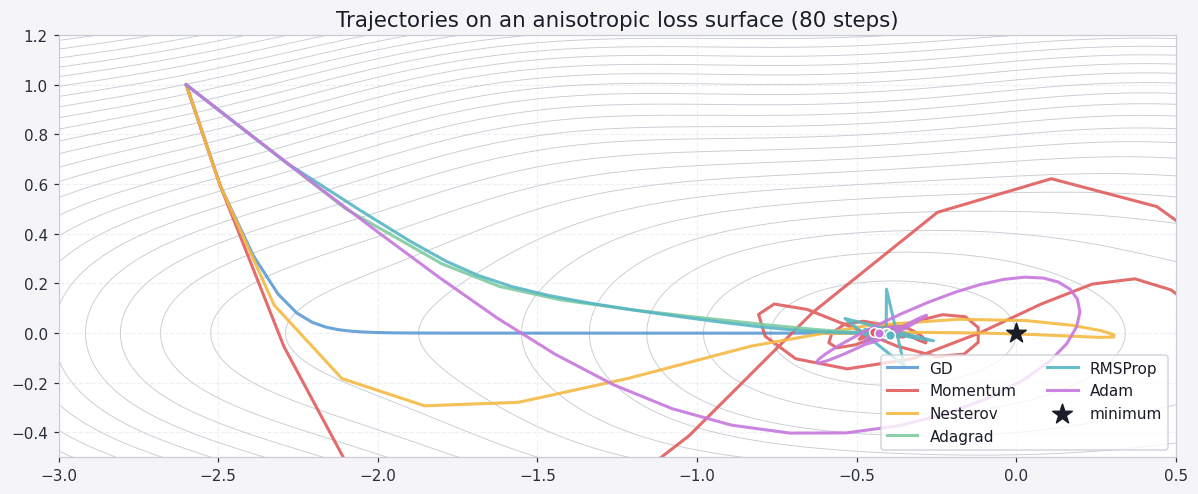

In [3]:
def run(update, p0, steps=80):
    p = np.array(p0, dtype=float); traj = [p.copy()]
    state = {}
    for t in range(1, steps+1):
        p = update(p, t, state)
        traj.append(p.copy())
    return np.array(traj)

def gd(eta=0.04):
    def step(p, t, s): return p - eta*grad(p)
    return step

def momentum(eta=0.04, beta=0.9):
    def step(p, t, s):
        s['v'] = beta*s.get('v', 0) + grad(p)
        return p - eta*s['v']
    return step

def nesterov(eta=0.04, beta=0.9):
    def step(p, t, s):
        v = s.get('v', np.zeros_like(p))
        look = p - eta*beta*v
        v = beta*v + grad(look)
        s['v'] = v
        return p - eta*v
    return step

def adagrad(eta=0.5, eps=1e-8):
    def step(p, t, s):
        g = grad(p); s['G'] = s.get('G', 0) + g*g
        return p - eta*g/np.sqrt(s['G']+eps)
    return step

def rmsprop(eta=0.1, beta=0.9, eps=1e-8):
    def step(p, t, s):
        g = grad(p); s['G'] = beta*s.get('G', 0) + (1-beta)*g*g
        return p - eta*g/np.sqrt(s['G']+eps)
    return step

def adam(eta=0.2, b1=0.9, b2=0.999, eps=1e-8):
    def step(p, t, s):
        g = grad(p)
        s['m'] = b1*s.get('m', 0) + (1-b1)*g
        s['v'] = b2*s.get('v', 0) + (1-b2)*g*g
        mh = s['m']/(1-b1**t); vh = s['v']/(1-b2**t)
        return p - eta*mh/(np.sqrt(vh)+eps)
    return step

opts = {'GD': gd(), 'Momentum': momentum(), 'Nesterov': nesterov(),
        'Adagrad': adagrad(), 'RMSProp': rmsprop(), 'Adam': adam()}
trajs = {name: run(u, [-2.6, 1.0]) for name, u in opts.items()}

fig, ax = plt.subplots(figsize=(11, 4.6))
ax.contour(xx, yy, ZZ, levels=30, colors='#c8ccd4', linewidths=0.6)
for (name, t), c in zip(trajs.items(), PALETTE):
    ax.plot(t[:,0], t[:,1], color=c, lw=2, label=name, alpha=0.9)
    ax.scatter(t[-1,0], t[-1,1], color=c, s=40, zorder=5, edgecolor='white')
ax.scatter(0, 0, marker='*', s=180, color='#1a1d27', zorder=6, label='minimum')
ax.set_xlim(-3, 0.5); ax.set_ylim(-0.5, 1.2)
ax.set_title('Trajectories on an anisotropic loss surface (80 steps)')
ax.legend(ncol=2, loc='lower right'); ax.grid(True)
plt.tight_layout(); plt.show()


---
## Loss vs iteration

Same trajectories, plotted as $\mathcal L(\theta_t)$.


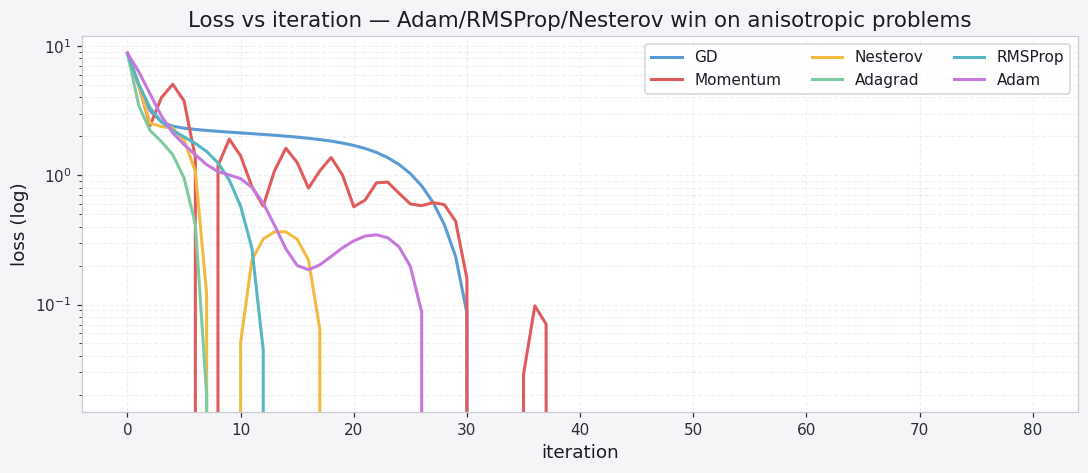

In [4]:
fig, ax = plt.subplots(figsize=(10, 4.4))
for (name, t), c in zip(trajs.items(), PALETTE):
    losses = [f(p[0], p[1]) for p in t]
    ax.plot(losses, color=c, lw=2, label=name)
ax.set_yscale('log')
ax.set_xlabel('iteration'); ax.set_ylabel('loss (log)')
ax.set_title('Loss vs iteration — Adam/RMSProp/Nesterov win on anisotropic problems')
ax.legend(ncol=3); ax.grid(True, which='both')
plt.tight_layout(); plt.show()


---
## Learning-rate sensitivity

Same optimizer (vanilla GD), three step sizes — too small, just right, too big.


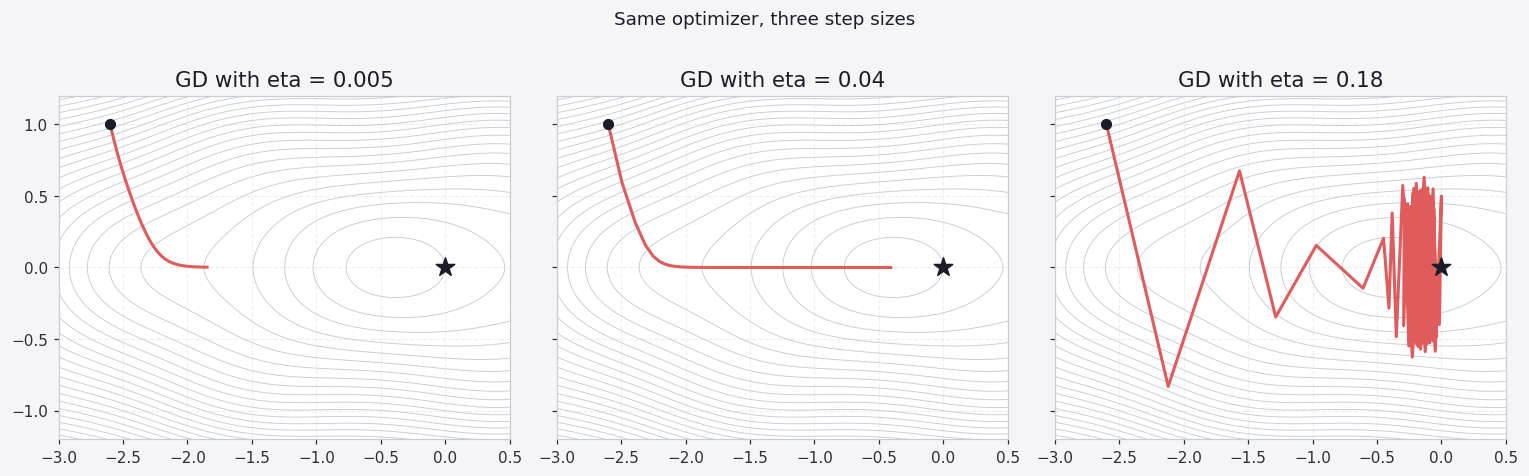

In [5]:
etas = [0.005, 0.04, 0.18]
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), sharey=True)
for ax, eta in zip(axes, etas):
    ax.contour(xx, yy, ZZ, levels=25, colors='#c8ccd4', linewidths=0.6)
    t = run(gd(eta), [-2.6, 1.0], steps=120)
    ax.plot(t[:,0], t[:,1], color=PALETTE[1], lw=2)
    ax.scatter(t[0,0], t[0,1], color='#1a1d27', s=40, zorder=5)
    ax.scatter(0, 0, marker='*', s=160, color='#1a1d27', zorder=6)
    ax.set_xlim(-3, 0.5); ax.set_ylim(-1.2, 1.2)
    ax.set_title(f'GD with eta = {eta}')
    ax.grid(True)
fig.suptitle('Same optimizer, three step sizes', y=1.02)
plt.tight_layout(); plt.show()


---
## When to use what

- **GD / Momentum** — convex problems, well-conditioned features.
- **Nesterov** — when momentum overshoots.
- **Adagrad** — sparse features (text, embeddings) with rare-but-informative dimensions (dims).
- **RMSProp / Adam** — non-stationary objectives, deep neural networks (deep nets), default if unsure.

> **Try this**: change the loss to `f = 0.5*(x**2 + y**2)` (isotropic). All optimizers converge in similar steps — the anisotropy is what makes Adam/RMSProp shine.